In [3]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [4]:
df = pd.read_csv('C:\\Users\\nayef\\OneDrive\\Desktop\\telecom-churn-analysis\\data\\raw\\telco_churn.csv')

# print the dataset shape and rows and cols
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

df.head() # display the 
df.info() # get info about the dataset

Dataset shape: (7043, 21)
Rows: 7043, Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   objec

In [5]:
# now we check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# totalCharges sum
df['TotalCharges'].describe()

# get the datatype of totalCharges
print(f"TotalCharges data type: {df['TotalCharges'].dtype}")

# check for non-numeric values 
non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"\nRows with non-numeric TotalCharges: {len(non_numeric)}")
print(non_numeric[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

# now we analyze the churn distribution
churn_counts = df['Churn'].value_counts()
churn_rate = (churn_counts['Yes'] / len(df)) * 100

print(f"Churn rate: {churn_rate: .2f}%")
print(f"Churned: {churn_counts['Yes']}")
print(f"Not Churned: {churn_counts['No']}")



Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
TotalCharges data type: object

Rows with non-numeric TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
Churn rate:  26.54%
Churned: 1869
Not Churned: 5174


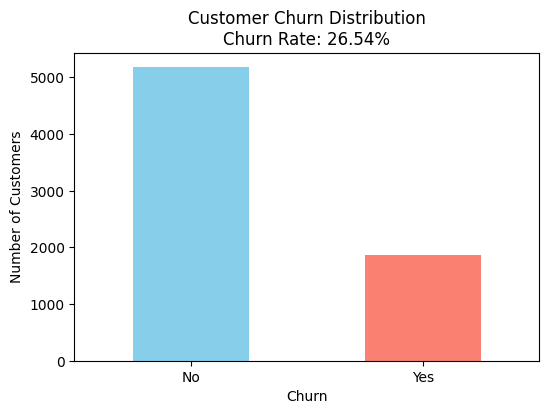

In [6]:
# visualization of the churn distribution
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title(f'Customer Churn Distribution\nChurn Rate: {churn_rate:.2f}%')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()


Revenue Analysis: 
Total Monthly Revenue: $456,116.60
Total Revenue (all time): $16,056,168.70
Revenue lost due to churn: $2,862,926.90
% of Revenue Churned: 17.83%


C:\Users\nayef\AppData\Local\Temp\ipykernel_25484\2938263569.py:26: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(['Retained'], ['Churned'])


<Figure size 1000x600 with 0 Axes>

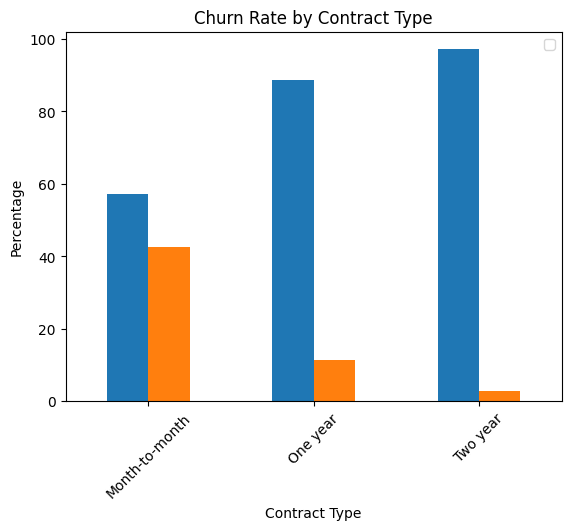

In [10]:
# Revenue Analysis
print("\nRevenue Analysis: ")
print(f"Total Monthly Revenue: ${df['MonthlyCharges'].sum():,.2f}")

# receive only valid TotalCharges values
df_valid = df[pd.to_numeric(df['TotalCharges'], errors='coerce').notna()].copy() # this copies only the valid rows to a new dataframe
df_valid['TotalCharges'] = pd.to_numeric(df_valid['TotalCharges']) # convert to numeric

total_revenue = df_valid['TotalCharges'].sum()
churned_revenue = df_valid[df_valid['Churn'] == 'Yes']['TotalCharges'].sum()

print(f"Total Revenue (all time): ${total_revenue:,.2f}")
print(f"Revenue lost due to churn: ${churned_revenue:,.2f}")
print(f"% of Revenue Churned: {(churned_revenue / total_revenue) * 100:.2f}%")

# contract vs churn
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(10, 6))
contract_churn.plot(kind='bar', stacked=False)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(['Retained'], ['Churned'])
plt.xticks(rotation=45)
plt.show()


C:\Users\nayef\AppData\Local\Temp\ipykernel_25484\218953440.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([retained, churned], labels=['Retained', 'Churned'])


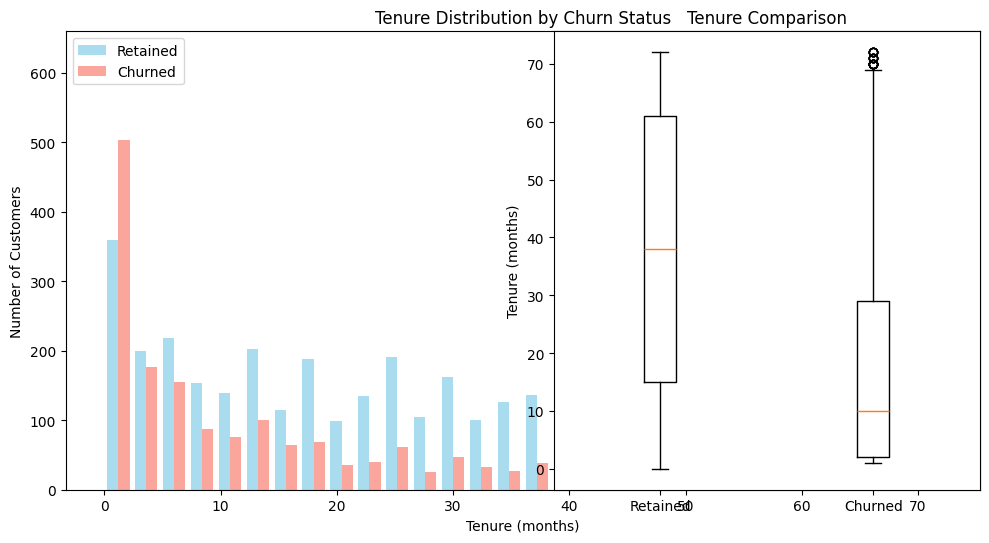

Average tenure - Retained: 37.6 months
Average tenure - Churned: 18.0 months

 Key Finding: 
1. Churn Rate: 26.54% of customers have churned
2. Month-to-month contracts have the highest churn
3. Churned customers have 19.6 months shorter tenure on average than retained customers
4. Revenue at risk due to churn: $2,862,926.90 which is 17.83 % of total revenue


In [12]:
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

plt.figure(figsize=(10, 6))
plt.hist([retained, churned], bins=30, label=['Retained', 'Churned'], color=['skyblue', 'salmon'], alpha=0.7)
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Tenure Distribution by Churn Status')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([retained, churned], labels=['Retained', 'Churned'])
plt.ylabel('Tenure (months)')
plt.title('Tenure Comparison')

plt.tight_layout()
plt.show()

print(f"Average tenure - Retained: {retained.mean():.1f} months")
print(f"Average tenure - Churned: {churned.mean():.1f} months")

# final summary of key insights extracted
print("\n Key Finding: ")
print(f"1. Churn Rate: {churn_rate:.2f}% of customers have churned")
print(f"2. Month-to-month contracts have the highest churn")
print(f"3. Churned customers have {retained.mean() - churned.mean():.1f} months shorter tenure on average than retained customers")
print(f"4. Revenue at risk due to churn: ${churned_revenue:,.2f} which is {(churned_revenue / total_revenue) * 100:.2f} % of total revenue")
